# Kaggle Credit Card Fraud Detection - Exploratory Data Analyzis
---
Students: 
- Levente Staub (243756)
- Gergő Honyák (242720)
- Máté Kovásznai (241960)
---
## Overview

This notebook performs an **end-to-end Exploratory Data Analysis (EDA)** on the Kaggle Credit Card Fraud Detection dataset.
The dataset contains transactions made by credit cards over **two days in September 2013** by European cardholders. It presents transactions that occurred and labels them as **fraudulent (Class=1)** or **legitimate (Class=0)**.

### What we'll explore:
1. **Dataset overview** — shape, types, missing values
2. **Class imbalance** — understanding the fraud/non-fraud ratio
3. **Time & Amount patterns** — when and how much fraud happens
4. **Outlier detection** — identifying extreme values
5. **Correlation analysis** — finding which features relate to fraud
6. **Feature distributions** — understanding V1–V28 (PCA-transformed) and Amount/Time

---

In [1]:
# Importing Necessary libaries

import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

# Dataset path
path = "../data/creditcard.csv"

In [2]:
COLORS = {'legit': '#2196F3', 'fraud': '#F44336'}

In [3]:
df = pd.read_csv(path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df['Class'] = df['Class'].astype(int)
df['Class'].dtypes

dtype('int64')

In [5]:
print(f"duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"duplicates after: {df.duplicated().sum()}")

duplicates before: 1081
duplicates after: 0


In [6]:
cols =df[["Amount","Time","Class"]]
cols.describe().T

,count,mean,std,min,25%,50%,75%,max
Amount,283726.0,88.472687,250.399437,0.0,5.60,22.0,77.51,25691.16
Time,283726.0,94811.077600,47481.047891,0.0,54204.75,84692.5,139298.00,172792.00
Class,283726.0,0.001667,0.040796,0.0,0.00,0.0,0.00,1.00


In [7]:
#unique values count of all colums
def check_classes(df):  
    dict = {}
    for i in list(df.columns):
        dict[i] = df[i].value_counts().shape[0]

    unq = pd.DataFrame(dict,index=["Unique Count"]).transpose().sort_values(by="Unique Count", ascending=False)
    return unq

check_classes(df)

,Unique Count
V1,275663
V2,275663
V3,275663
V5,275663
V4,275663
V6,275663
V7,275663
V11,275663
V8,275663
V9,275663


Class
0    283253
1       473
Name: count, dtype: int64


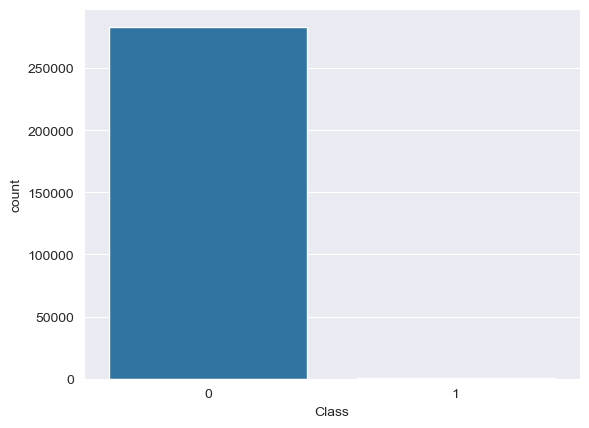

In [8]:
# Plot number of rows / class

sns.countplot(data = df, x='Class')
print(df['Class'].value_counts())

This plot suggests that there is a severe class imbalance, let's dive into it further

In [9]:
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100


ratio = class_counts[0] / class_counts[1]

print(f'Fraud transactions: {class_counts[1]:,} ({class_pct[1]:.3f}%)')
print(f'Legit transactions: {class_counts[0]:,} ({class_pct[0]:.3f}%)')
print(f'Imbalance ratio: 1:{ratio:.0f}')

Fraud transactions: 473 (0.167%)
Legit transactions: 283,253 (99.833%)
Imbalance ratio: 1:599


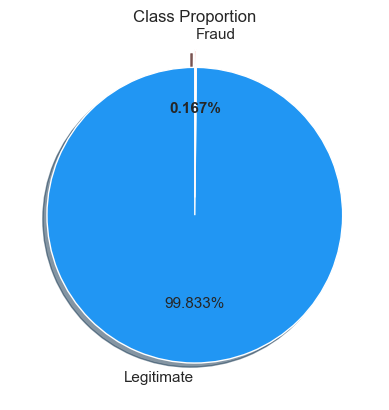

In [10]:
PALETTE = [COLORS['legit'], COLORS['fraud']]


wedges, texts, autotexts = plt.pie(
    class_counts.values,
    labels=['Legitimate', 'Fraud'],
    colors=PALETTE,
    autopct='%1.3f%%',
    startangle=90,
    explode=(0, 0.12),
    shadow=True,
    textprops={'fontsize': 11}
)

autotexts[1].set_fontweight('bold')
plt.title('Class Proportion')

plt.show()

The dataset is **extremely imbalanced**, only **0.173% of transactions are fraudulent** (~1 in 577). This is realistic for real-world fraud data. The key implications are:
- Standard accuracy is **meaningless** here as a metric.
- We must use **F1-score, AUC-ROC, Precision-Recall AUC** to evaluate models properly.
- During training, we'll need techniques like **SMOTE, class weighting, or undersampling** to prevent the model from ignoring the minority (fraud) class.


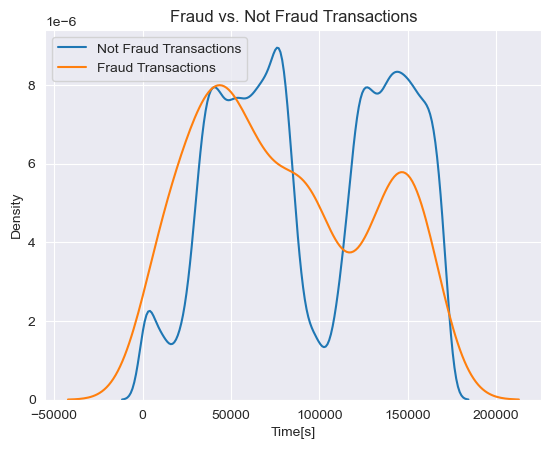

In [11]:
class_0 = df.loc[df['Class'] == 0]["Time"]
class_1 = df.loc[df['Class'] == 1]["Time"]

sns.kdeplot(data=class_0, label="Not Fraud Transactions", fill=False)
sns.kdeplot(data=class_1, label="Fraud Transactions", fill=False)
# Add labels and title
plt.xlabel("Time[s]")
plt.ylabel("Density")
plt.title("Fraud vs. Not Fraud Transactions")

# Add legend
plt.legend()

# Display the plot
plt.show()

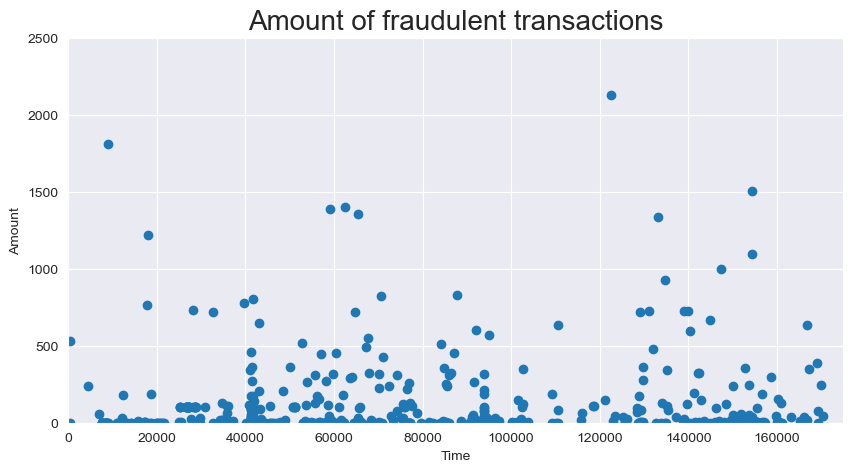

In [12]:
df_fraud = df[df['Class'] == 1] # Recovery of fraud data
plt.figure(figsize=(10,5))
plt.scatter(df_fraud['Time'], df_fraud['Amount']) # Display fraud amounts according to their time
plt.title('Amount of fraudulent transactions',size=20)
plt.xlabel('Time')
plt.ylabel('Amount')
plt.xlim([0,175000])
plt.ylim([0,2500])
plt.show()

In [13]:
# Create new feature for better visualizations

df['hour'] = (df['Time'] / 3600).astype(int)
fraud_df    = df[df['Class'] == 1]
legit_df    = df[df['Class'] == 0]


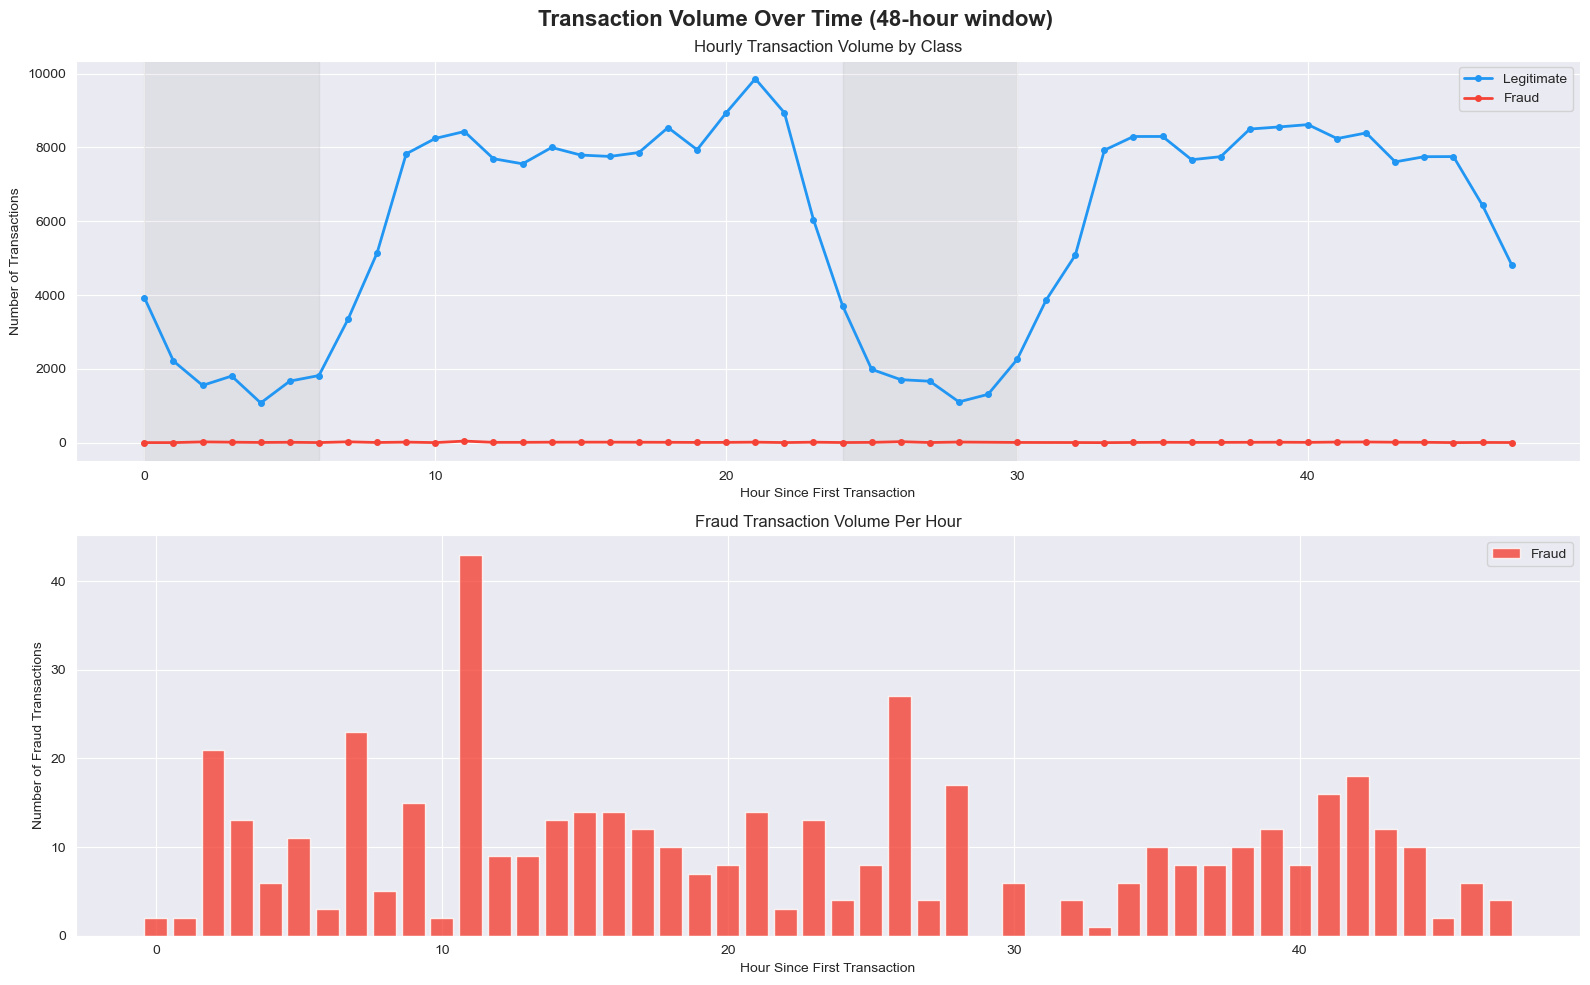

In [14]:
# Transaction volume over time 
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Transaction Volume Over Time (48-hour window)', fontsize=16, fontweight='bold')

COLORS = {'legit': '#2196F3', 'fraud': '#F44336'}

# Hourly transaction counts by class
for cls, label, color in [(0, 'Legitimate', COLORS['legit']), (1, 'Fraud', COLORS['fraud'])]:
    subset = df[df['Class'] == cls]
    hourly = subset.groupby('hour').size()
    axes[0].plot(hourly.index, hourly.values, color=color, label=label,
                linewidth=2, marker='o', markersize=4)

axes[0].set_title('Hourly Transaction Volume by Class')
axes[0].set_xlabel('Hour Since First Transaction')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()
axes[0].axvspan(0, 6, alpha=0.1, color='gray', label='Likely night hours')
axes[0].axvspan(24, 30, alpha=0.1, color='gray')

# Fraud only - to see its pattern more clearly (scaled)
fraud_hourly = fraud_df.groupby('hour').size()
axes[1].bar(fraud_hourly.index, fraud_hourly.values, color=COLORS['fraud'], alpha=0.8, label='Fraud')
axes[1].set_title('Fraud Transaction Volume Per Hour')
axes[1].set_xlabel('Hour Since First Transaction')
axes[1].set_ylabel('Number of Fraud Transactions')
axes[1].legend()

plt.tight_layout()
plt.show()

Legitimate transactions follow a clear **daily cycle**  high during daytime hours, low at night, which is expected human behavior. Fraud transactions show a **more uniform distribution across hours**, with some concentration in the first 12 hours. This suggests that fraudsters are less constrained by normal waking hours, consistent with automated fraud bots or attackers operating across time zones.

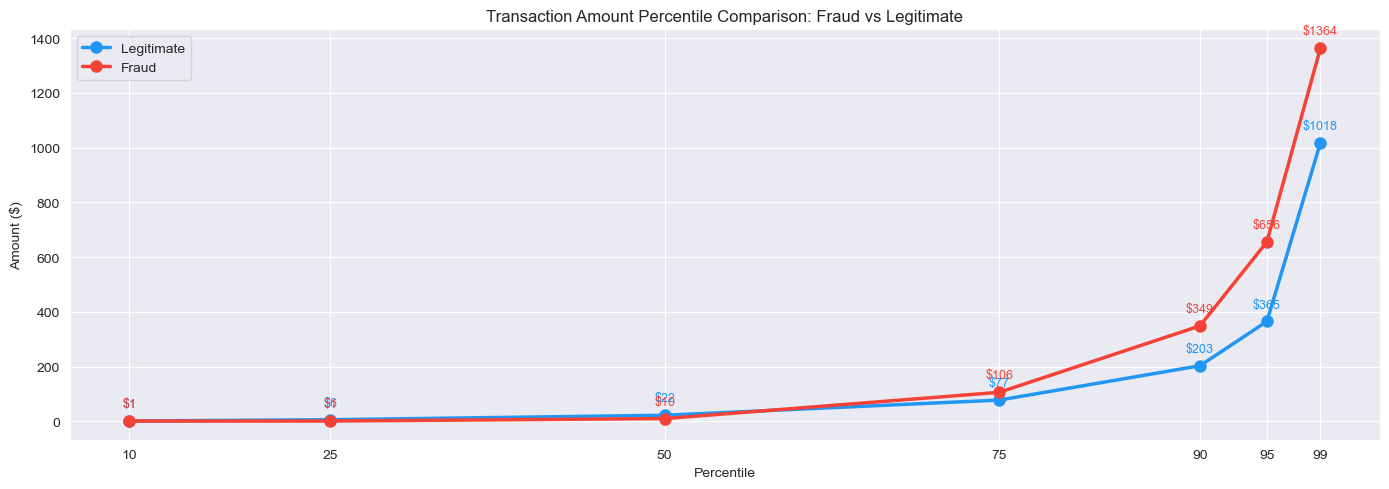

In [15]:
# Amount percentile breakdown 
fig, ax = plt.subplots(figsize=(14, 5))

percentiles = [10, 25, 50, 75, 90, 95, 99]
for cls, label, color in [(0, 'Legitimate', COLORS['legit']), (1, 'Fraud', COLORS['fraud'])]:
    vals = [df[df['Class'] == cls]['Amount'].quantile(p/100) for p in percentiles]
    ax.plot(percentiles, vals, marker='o', label=label, color=color, linewidth=2.5, markersize=8)
    for p, v in zip(percentiles, vals):
        ax.annotate(f'${v:.0f}', (p, v), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9, color=color)

ax.set_title('Transaction Amount Percentile Comparison: Fraud vs Legitimate')
ax.set_xlabel('Percentile')
ax.set_ylabel('Amount ($)')
ax.legend()
ax.set_xticks(percentiles)

plt.tight_layout()
plt.show()

At nearly every percentile, **fraud amounts are lower than legitimate amounts**. Notably, the 99th percentile fraud amount is dramatically lower than legitimate, indicating that extremely large transactions are almost exclusively legitimate. This insight could directly be used as a simple rule-based fraud filter.

C:\Users\leven\AppData\Local\Temp\ipykernel_15008\3868575126.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t0[feature], bw_method=0.5, label="Class = 0")
C:\Users\leven\AppData\Local\Temp\ipykernel_15008\3868575126.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t1[feature], bw_method=0.5, label="Class = 1")


<Figure size 640x480 with 0 Axes>

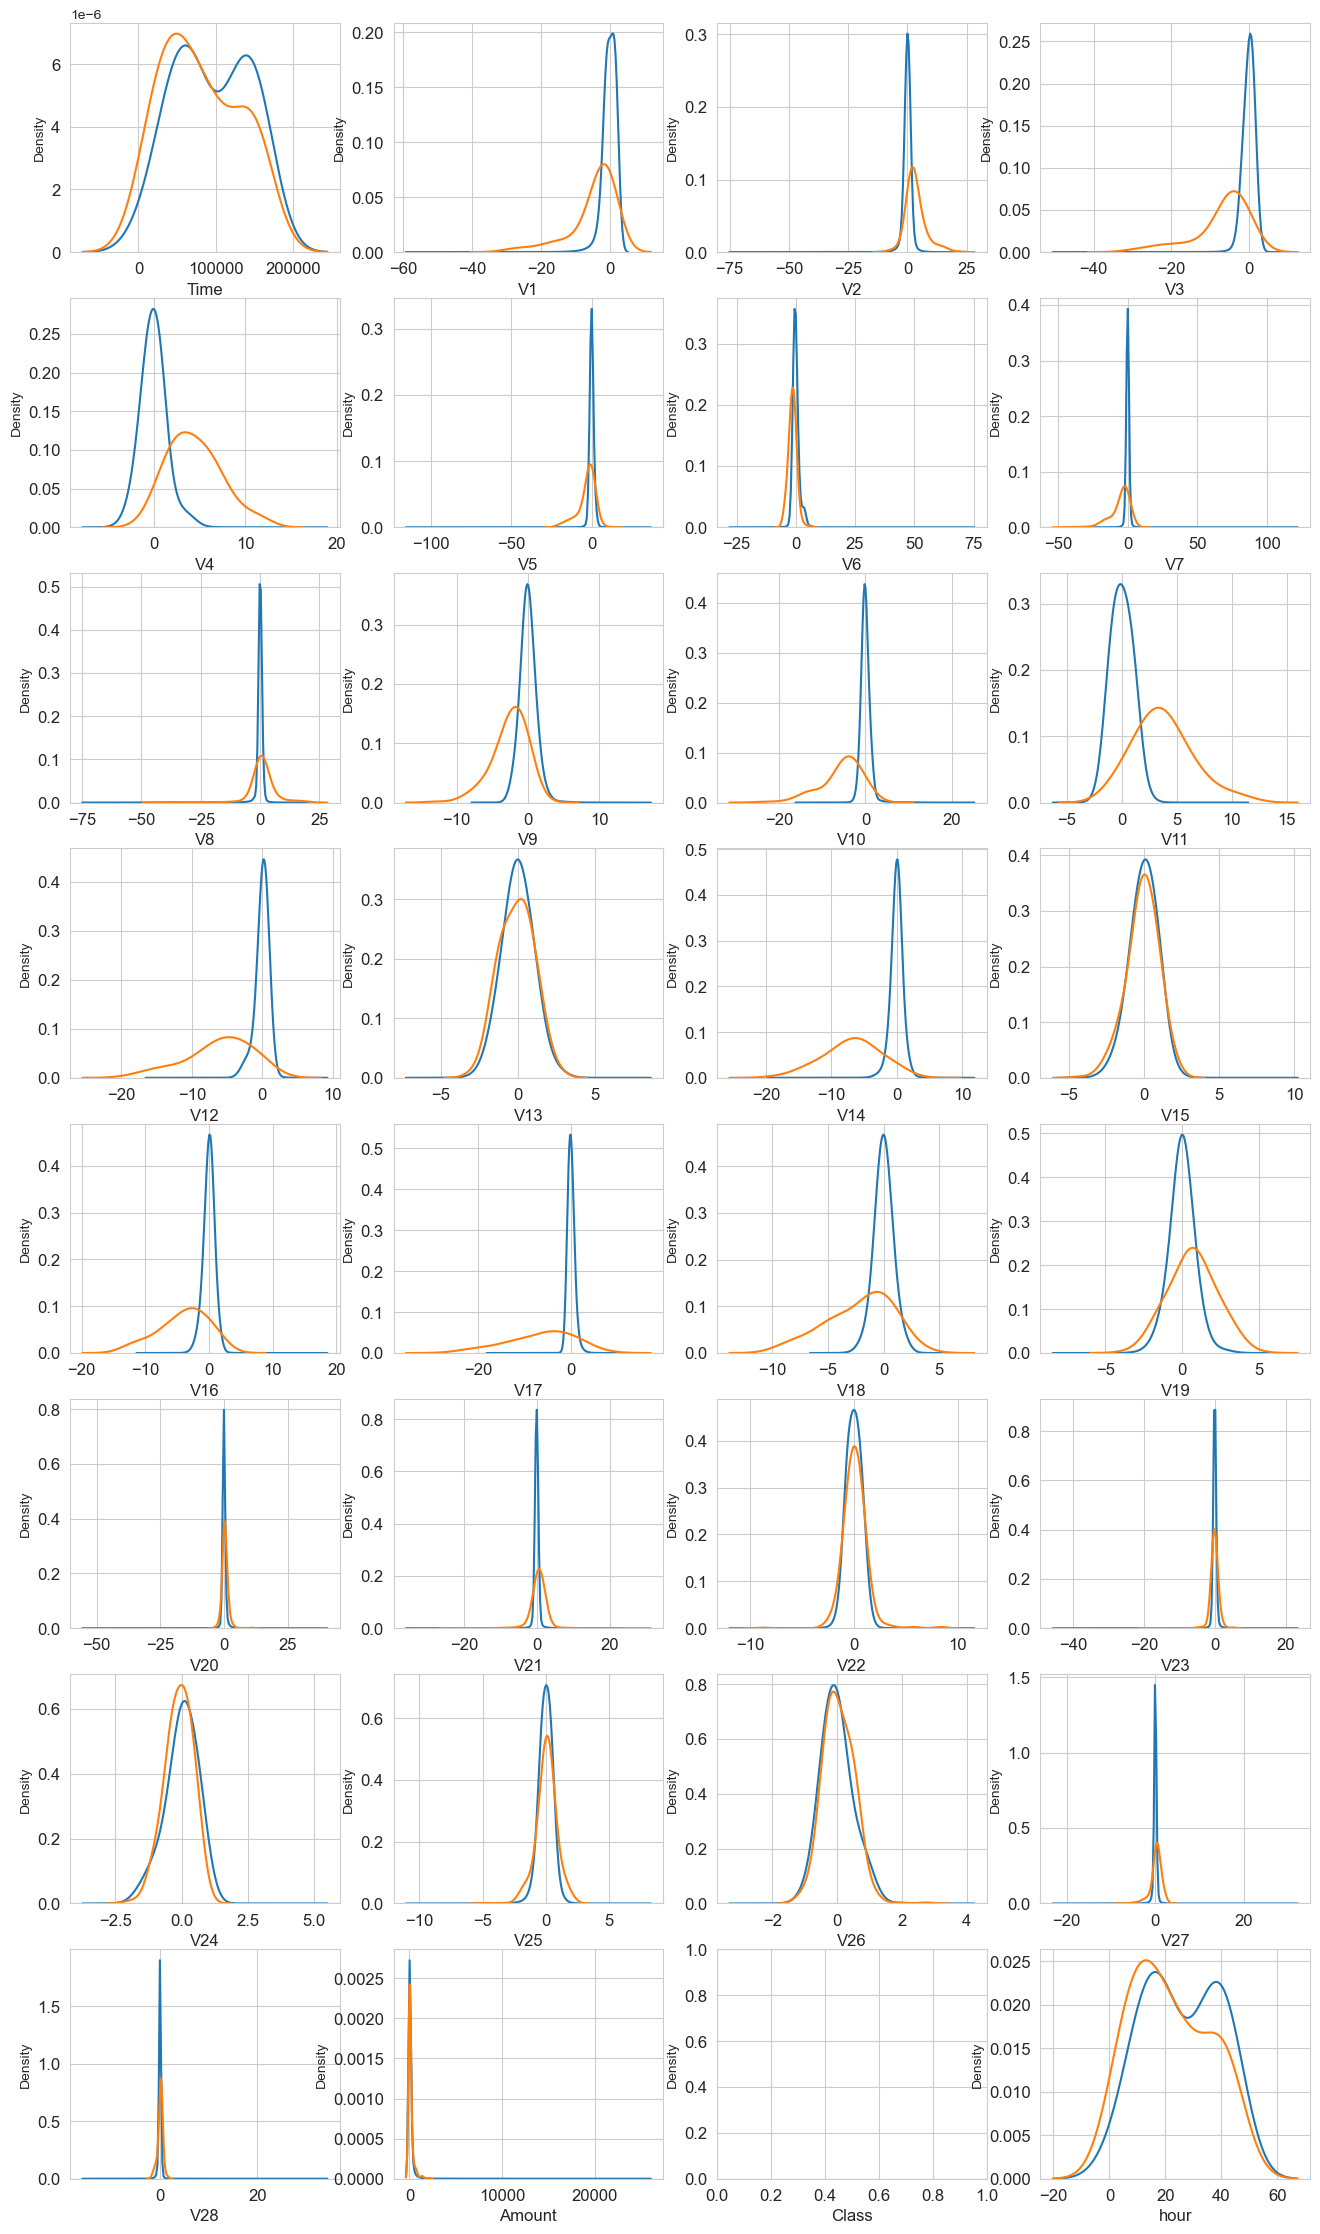

In [16]:
var = df.columns.values

i = 0
t0 = df.loc[df['Class'] == 0]
t1 = df.loc[df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw_method=0.5, label="Class = 0")
    sns.kdeplot(t1[feature], bw_method=0.5, label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

These KDE plots visually confirm the KS statistics. The **red (fraud) and blue (legitimate) curves are clearly offset** for the top features, meaning there are feature values that are much more common in one class than the other. This is exactly the kind of signal machine learning models learn to exploit. Features with near-perfect separation (KS > 0.5) alone could serve as simple threshold rules.

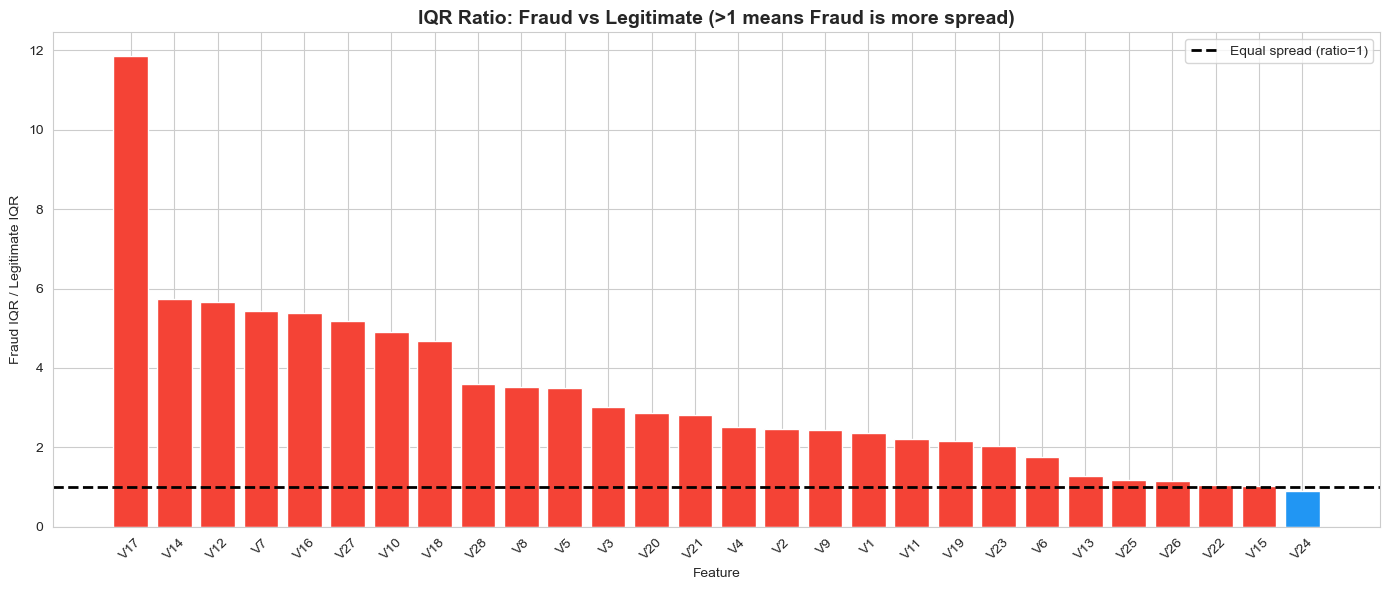

In [17]:
#  IQR range comparison: which features are more 'spread' in fraud 

v_features  = [f'V{i}' for i in range(1, 29)]   # PCA features

iqr_comparison = pd.DataFrame({
    'Legit IQR':  legit_df[v_features].quantile(0.75) - legit_df[v_features].quantile(0.25),
    'Fraud IQR':  fraud_df[v_features].quantile(0.75) - fraud_df[v_features].quantile(0.25),
})
iqr_comparison['IQR Ratio (Fraud/Legit)'] = iqr_comparison['Fraud IQR'] / iqr_comparison['Legit IQR']
iqr_comparison = iqr_comparison.sort_values('IQR Ratio (Fraud/Legit)', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['#F44336' if r > 1 else '#2196F3' for r in iqr_comparison['IQR Ratio (Fraud/Legit)']]
ax.bar(iqr_comparison.index, iqr_comparison['IQR Ratio (Fraud/Legit)'], color=bar_colors, edgecolor='white')
ax.axhline(1.0, color='black', linestyle='--', linewidth=2, label='Equal spread (ratio=1)')
ax.set_title('IQR Ratio: Fraud vs Legitimate (>1 means Fraud is more spread)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Fraud IQR / Legitimate IQR')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Features where the IQR ratio exceeds 1.0 (red bars) are **more variable in fraud than in legitimate transactions**. This means fraudulent transaction behavior is more erratic/diverse for those features. Conversely, some features (blue bars, ratio < 1) are actually more concentrated in fraud — fraudsters may behave in a consistent, narrow pattern for those dimensions (e.g., a bot always transacting with the same velocity).

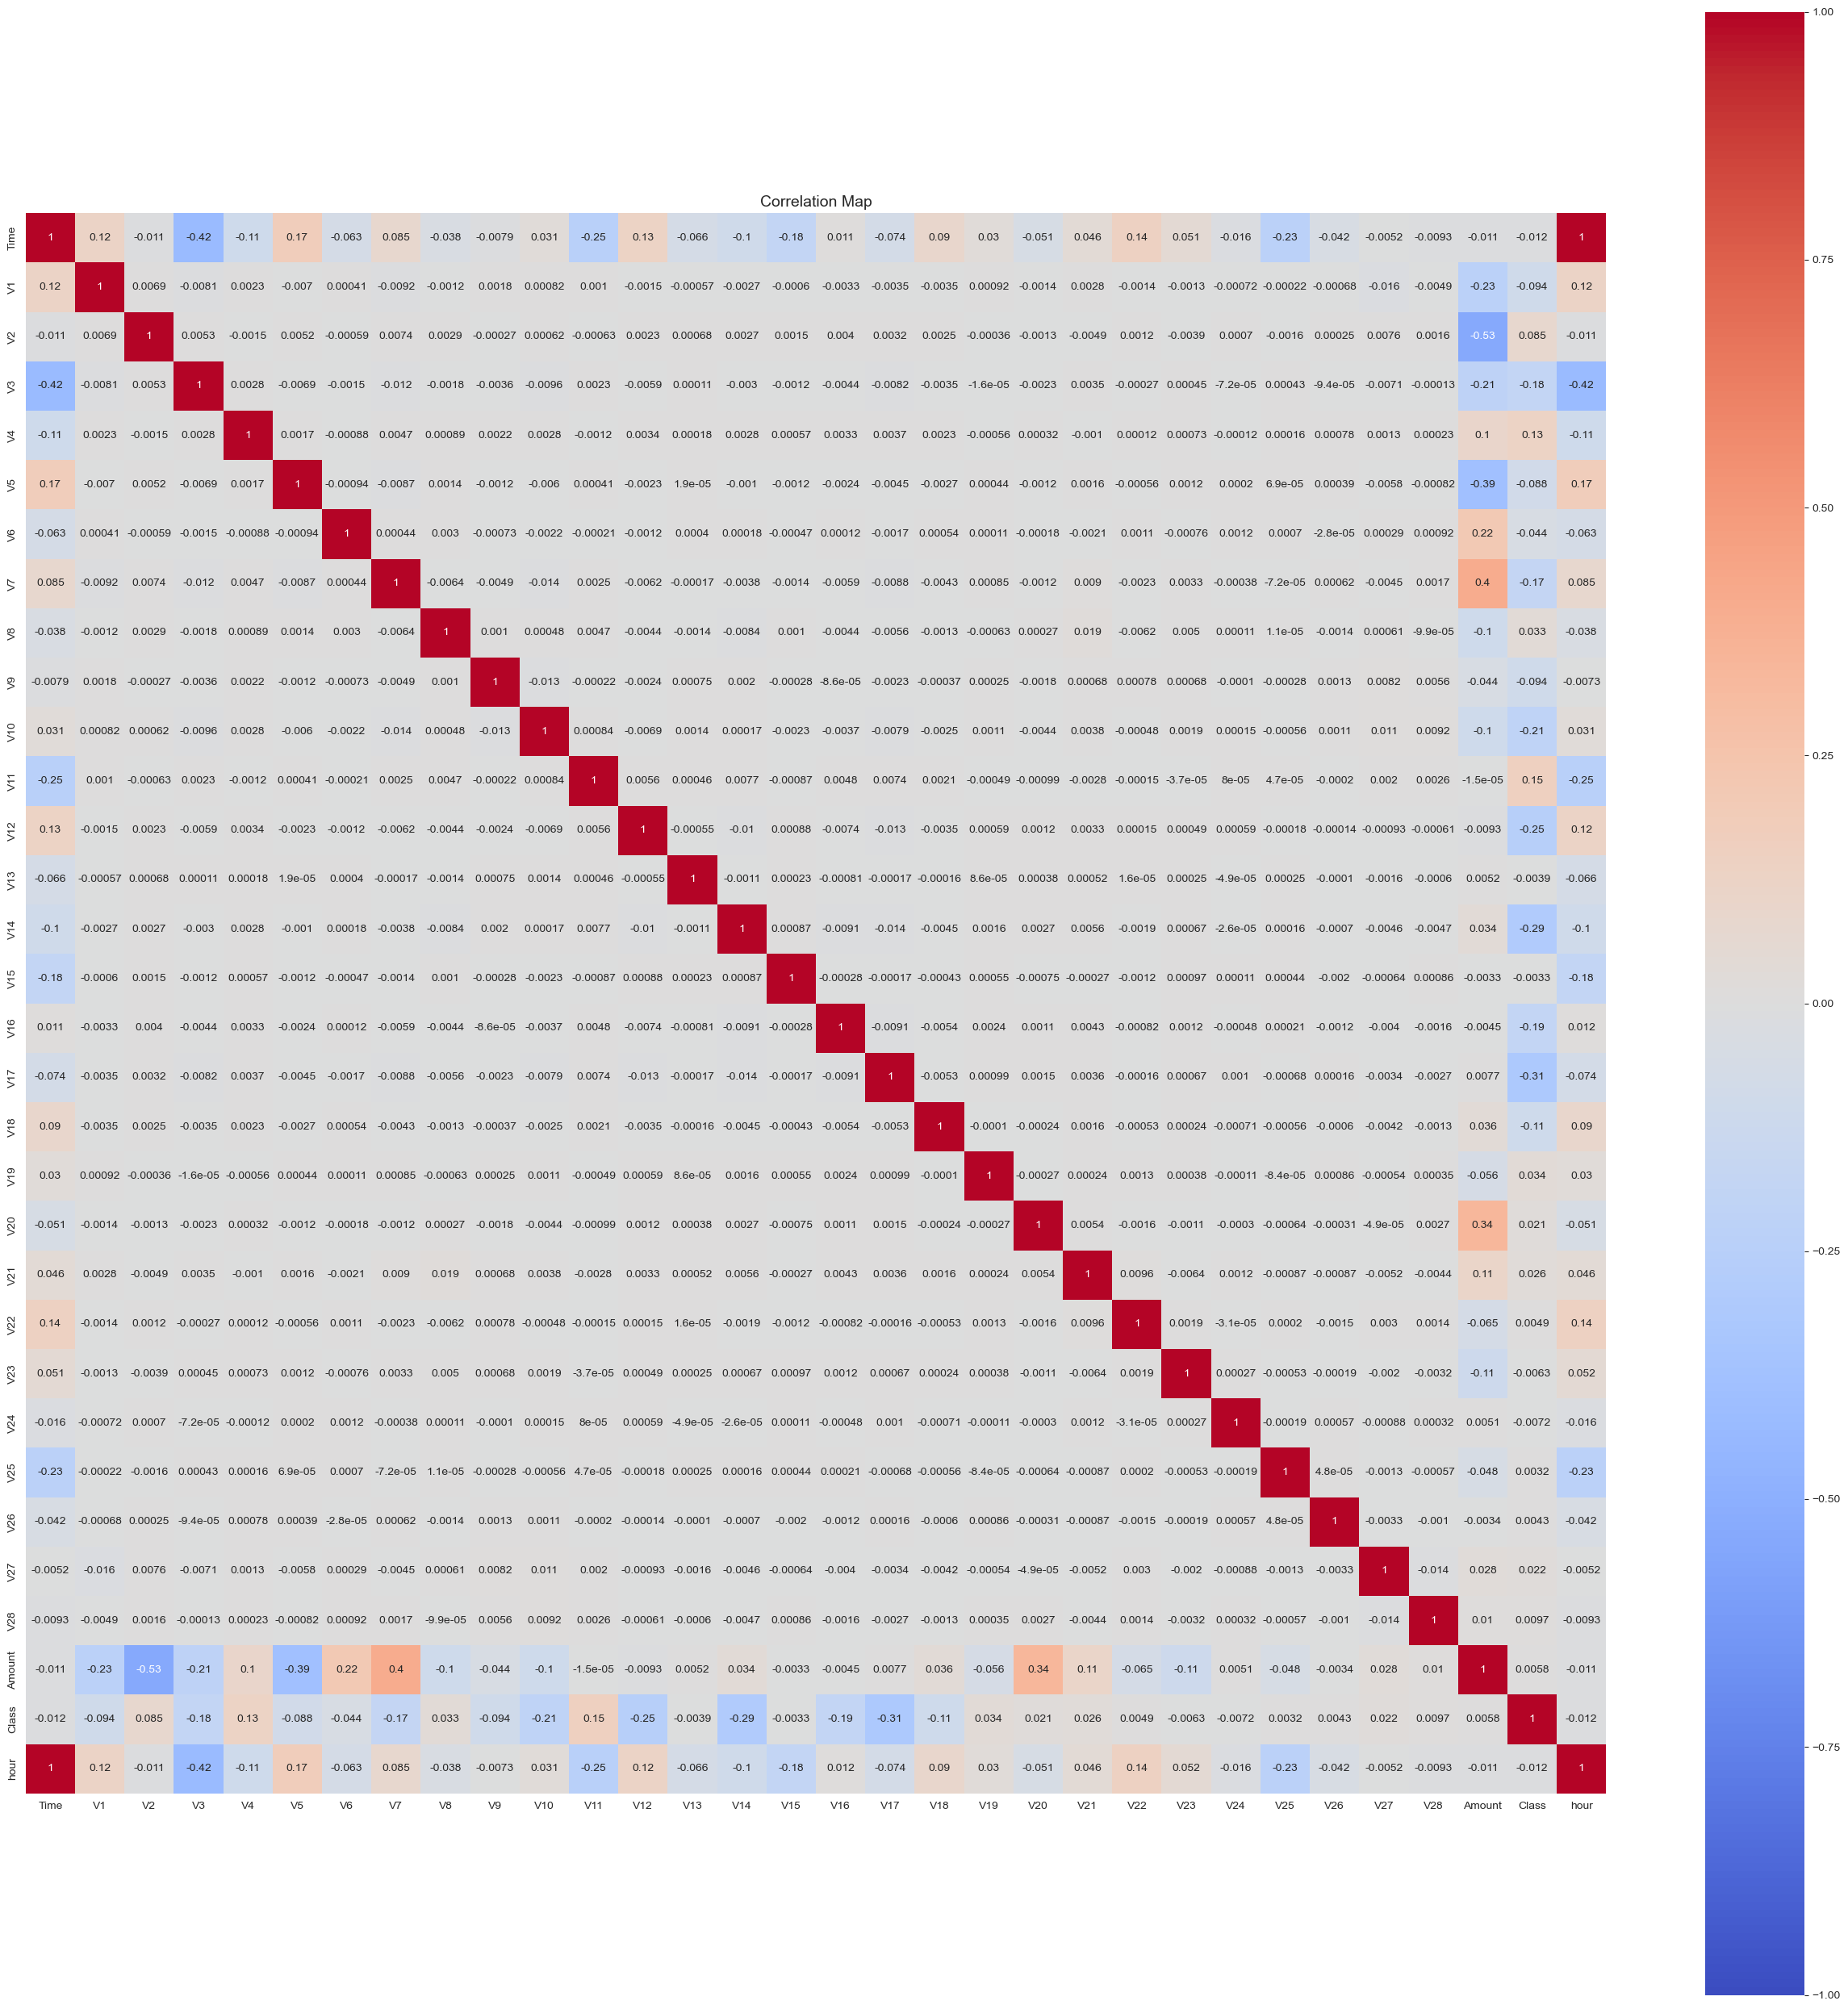

In [18]:
corr = df.corr()


# Plot the correlation heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(
    corr,
    annot=True,        # Show correlation values
    cmap='coolwarm',   # Color map
    vmin=-1, vmax=1,   # Correlation range
    square=True
)

plt.title('Correlation Map', fontsize=14)
plt.tight_layout()
plt.show()

**near-zero correlation with each other** the off-diagonal cells are all close to white (zero correlation). The most interesting column is `Class` (bottom/right), where some features show meaningful positive or negative correlations. The diagonal is always 1.0 (a feature perfectly correlates with itself).

In [19]:
ks_results = {}
for feat in v_features + ['Amount', 'Time']:
    stat, pval = ks_2samp(legit_df[feat], fraud_df[feat])
    ks_results[feat] = {'ks_stat': stat, 'p_value': pval, 'significant': pval < 0.05}

ks_df = pd.DataFrame(ks_results).T.sort_values('ks_stat', ascending=False)
ks_df['ks_stat'] = ks_df['ks_stat'].astype(float).round(4)


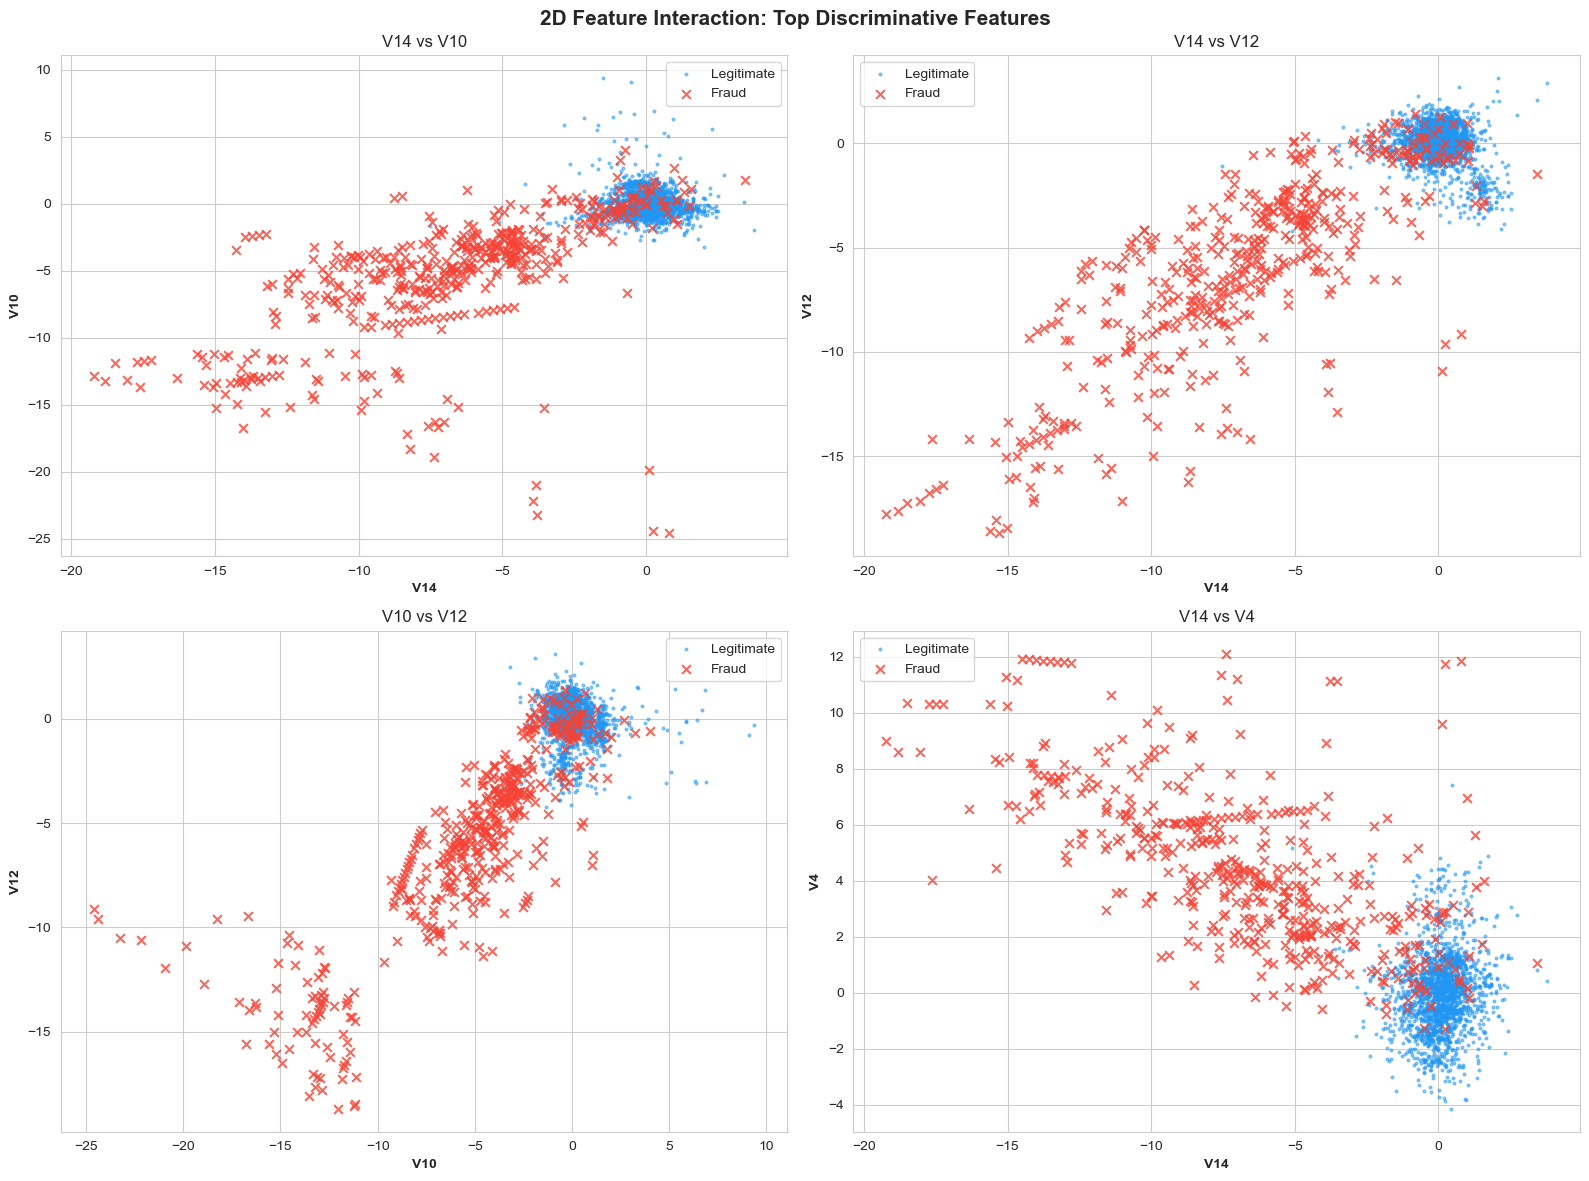

In [20]:
top4 = ks_df.head(4).index.tolist()
pairs = [(top4[0], top4[1]), (top4[0], top4[2]),
         (top4[1], top4[2]), (top4[0], top4[3])]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2D Feature Interaction: Top Discriminative Features', fontsize=15, fontweight='bold')
axes = axes.flatten()

# Sample for performance (all fraud + sample of legit)
legit_sample = legit_df.sample(n=2000, random_state=42)
plot_df = pd.concat([fraud_df, legit_sample])

for i, (fx, fy) in enumerate(pairs):
    for cls, label, color, marker in [(0, 'Legitimate', COLORS['legit'], '.'),
                                       (1, 'Fraud', COLORS['fraud'], 'x')]:
        subset = plot_df[plot_df['Class'] == cls]
        axes[i].scatter(subset[fx], subset[fy], c=color, label=label,
                       alpha=0.5 if cls == 0 else 0.8,
                       s=15 if cls == 0 else 40, marker=marker)
    axes[i].set_xlabel(fx, fontweight='bold')
    axes[i].set_ylabel(fy, fontweight='bold')
    axes[i].set_title(f'{fx} vs {fy}')
    axes[i].legend()
plt.tight_layout()
plt.show()

In 2D space, fraud (red X marks) and legitimate (blue dots) transactions show clear **spatial separation** when plotting the top features against each other. Fraud clusters in distinct regions of feature space. This visual separation is encouraging it tells us a classifier should be able to draw a meaningful decision boundary with relatively few features.

In [21]:
# Comprehensive feature summary table 

summary_rows = []
for feat in v_features + ['Amount', 'Time']:
    ks_stat, ks_p = ks_2samp(legit_df[feat], fraud_df[feat])
    corr_class = df[feat].corr(df['Class'])
    mean_legit = legit_df[feat].mean()
    mean_fraud = fraud_df[feat].mean()
    std_legit  = legit_df[feat].std()
    std_fraud  = fraud_df[feat].std()

    summary_rows.append({
        'Feature': feat,
        'KS Statistic': round(ks_stat, 4),
        'Corr w/ Class': round(corr_class, 4),
        'Mean (Legit)': round(mean_legit, 3),
        'Mean (Fraud)': round(mean_fraud, 3),
        'Std (Legit)': round(std_legit, 3),
        'Std (Fraud)': round(std_fraud, 3),
        'KS Significant': ks_p < 0.05
    })

summary_df = pd.DataFrame(summary_rows).set_index('Feature').sort_values('KS Statistic', ascending=False)
summary_df

,KS Statistic,Corr w/ Class,Mean (Legit),Mean (Fraud),Std (Legit),Std (Fraud),KS Significant
Feature,,,,,,,
V14,0.8377,-0.2934,0.012,-6.836,0.894,4.253,True
V10,0.7970,-0.2070,0.008,-5.453,1.036,4.706,True
V12,0.7766,-0.2507,0.009,-6.103,0.945,4.582,True
V4,0.7607,0.1293,-0.010,4.473,1.399,2.872,True
V11,0.7474,0.1491,-0.006,3.716,1.002,2.673,True
V17,0.7355,-0.3135,0.011,-6.463,0.749,6.966,True
V3,0.6952,-0.1823,0.013,-6.730,1.458,6.910,True
V16,0.6782,-0.1872,0.008,-4.001,0.845,3.832,True
V7,0.6516,-0.1723,0.010,-5.176,1.177,6.858,True


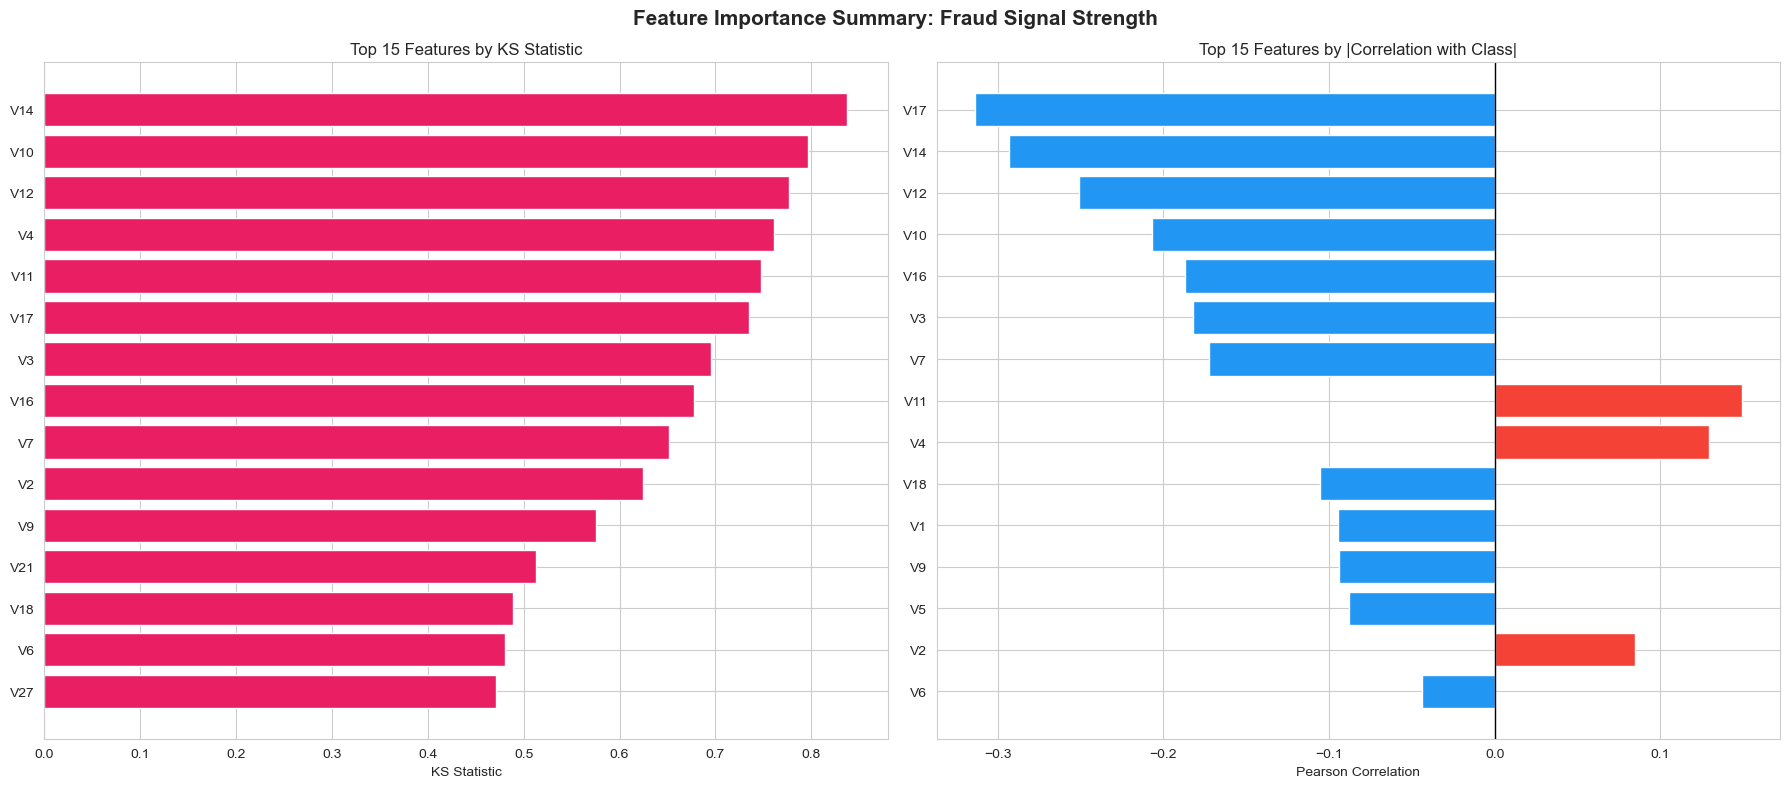

In [22]:
#  Final ranking visualization 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Summary: Fraud Signal Strength', fontsize=15, fontweight='bold')

# KS Statistic
top15 = summary_df.head(15)
axes[0].barh(top15.index[::-1], top15['KS Statistic'][::-1],
             color='#E91E63', edgecolor='white')
axes[0].set_title('Top 15 Features by KS Statistic')
axes[0].set_xlabel('KS Statistic')

# Correlation
top15_corr = summary_df.reindex(summary_df['Corr w/ Class'].abs().sort_values(ascending=False).head(15).index)
bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in top15_corr['Corr w/ Class'][::-1]]
axes[1].barh(top15_corr.index[::-1], top15_corr['Corr w/ Class'][::-1],
             color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Top 15 Features by |Correlation with Class|')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

Combining both the KS statistic and correlation ranking, we can identify a consistent set of **top predictive features**: V4, V11, V14, V17, V12, V10. These appear at the top of both rankings, meaning they both shift significantly (KS) and have a directional relationship with the target (correlation). These features should be prioritized during model training and are prime candidates for drift monitoring in production.

# EDA Summary and future directions

### Dataset Structure
- **284,807 transactions** over 48 hours; **492 fraud cases** (0.173%) a severely imbalanced dataset
- **No missing values** in the dataset
- Dataset is very clean and well-structured for ML work

### Class Imbalance
- The **1:577 imbalance ratio** makes standard accuracy meaningless
- **Required techniques:** SMOTE oversampling, class weights (`class_weight='balanced'`), threshold tuning
- **Required metrics:** F1-score, AUC-ROC, Precision-Recall AUC

### Time & Amount
- Transactions follow **human circadian rhythm** (high day, low night)
- Fraud shows **more uniform time distribution** bots operate 24/7
- Fraud amounts skew **lower** card testing behavior is common
- Raw Amount is **highly right-skewed** 

### Feature Discrimination
- **Top discriminative features:** V4, V11, V14, V17, V12, V10 (KS > 0.3)
- Several features show **near-zero discriminative power** → candidates for removal
- V1–V28 show expected **near-zero feature correlation** 

---

## Next Steps


1. **Threshold Tuning**  Default 0.5 threshold is likely suboptimal for this imbalance ratio
2. **Feature Engineering** Consider adding interaction terms for V4×V14, amount buckets, etc.
3. **Drift Detection** Use V4, V11, V14, V17 as primary drift monitoring features


---